# Exploration of the FER-2013 Facial Expression Dataset

This notebook provides an exploratory data analysis (EDA) of the **FER-2013** dataset used in this project. We will load the dataset, check basic statistics, plot the class distribution, inspect the splits, and visualize some sample face images.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Loading the Dataset

The dataset is stored in CSV format at `data/raw/fer2013.csv`. Let's load it and inspect its structure.

In [2]:
csv_path = Path("data/raw/fer2013.csv")
if not csv_path.exists():
    print("Error: Dataset CSV file not found. Make sure it is downloaded at 'data/raw/fer2013.csv'")
else:
    df = pd.read_csv(csv_path)
    print(f"Dataset shape: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())

Dataset shape: (35887, 3)

First 5 rows:
   emotion                                             pixels     Usage
0        2  109 150 198 219 251 254 254 253 250 231 205 19...  Training
1        3  125 130 101 102 102 94 98 116 109 101 116 107 ...  Training
2        3  34 38 34 54 52 35 40 53 94 124 130 144 150 154...  Training
3        3  167 167 167 168 169 170 170 171 165 167 182 19...  Training
4        6  49 40 57 67 68 73 92 107 105 99 104 121 138 15...  Training


## 2. Dataset Statistics

Let's map the numerical labels to their corresponding human-readable emotion names and check the counts.

In [3]:
emotion_labels = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "happiness",
    4: "sadness",
    5: "surprise",
    6: "neutral"
}

df["emotion_name"] = df["emotion"].map(emotion_labels)

print("=== Samples per usage split ===")
print(df["Usage"].value_counts())

print("\n=== Samples per emotion class ===")
class_counts = df["emotion_name"].value_counts()
for name, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{name:<10}: {count:>6} ({percentage:.2f}%)")

=== Samples per usage split ===
Usage
Training       25839
PrivateTest     7178
PublicTest      2870
Name: count, dtype: int64

=== Samples per emotion class ===
happiness :   8989 (25.05%)
neutral   :   6198 (17.27%)
sadness   :   6077 (16.93%)
fear      :   5121 (14.27%)
anger     :   4953 (13.80%)
surprise  :   4002 (11.15%)
disgust   :    547 (1.52%)


## 3. Class Distribution Analysis

There is a severe class imbalance in this dataset. Let's plot the distribution of emotion classes.

C:\Users\petrk\AppData\Local\Temp\ipykernel_126132\2214728676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


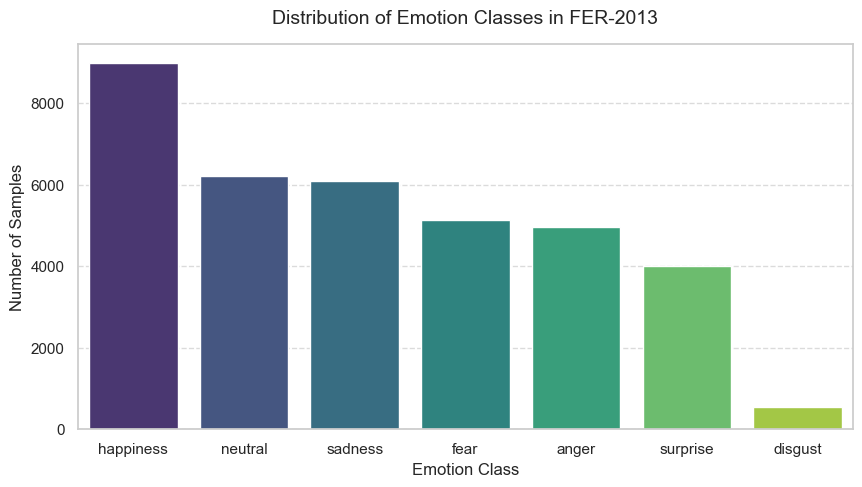

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    x="emotion_name", 
    order=df["emotion_name"].value_counts().index, 
    palette="viridis"
)
plt.title("Distribution of Emotion Classes in FER-2013", fontsize=14, pad=15)
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Let's also look at how classes are distributed across different splits (`Training`, `PublicTest`, `PrivateTest`).

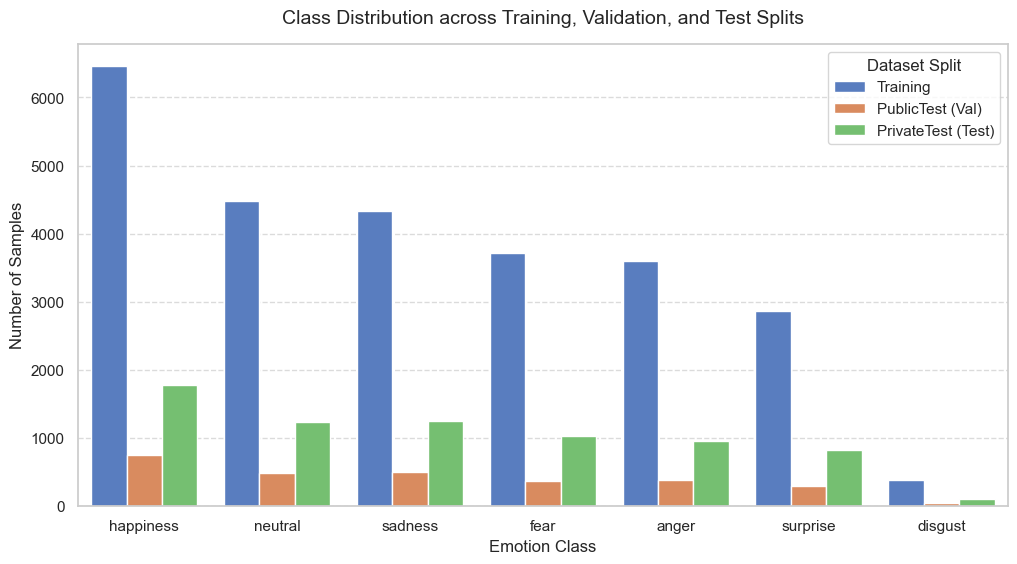

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, 
    x="emotion_name", 
    hue="Usage", 
    order=df["emotion_name"].value_counts().index,
    palette="muted"
)
plt.title("Class Distribution across Training, Validation, and Test Splits", fontsize=14, pad=15)
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Dataset Split", labels=["Training", "PublicTest (Val)", "PrivateTest (Test)"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Visualizing Sample Images

Each row in the dataset contains a single flat string of `2304` space-separated pixel values. Let's reshape them back to `48x48` grayscale images and view some actual samples.

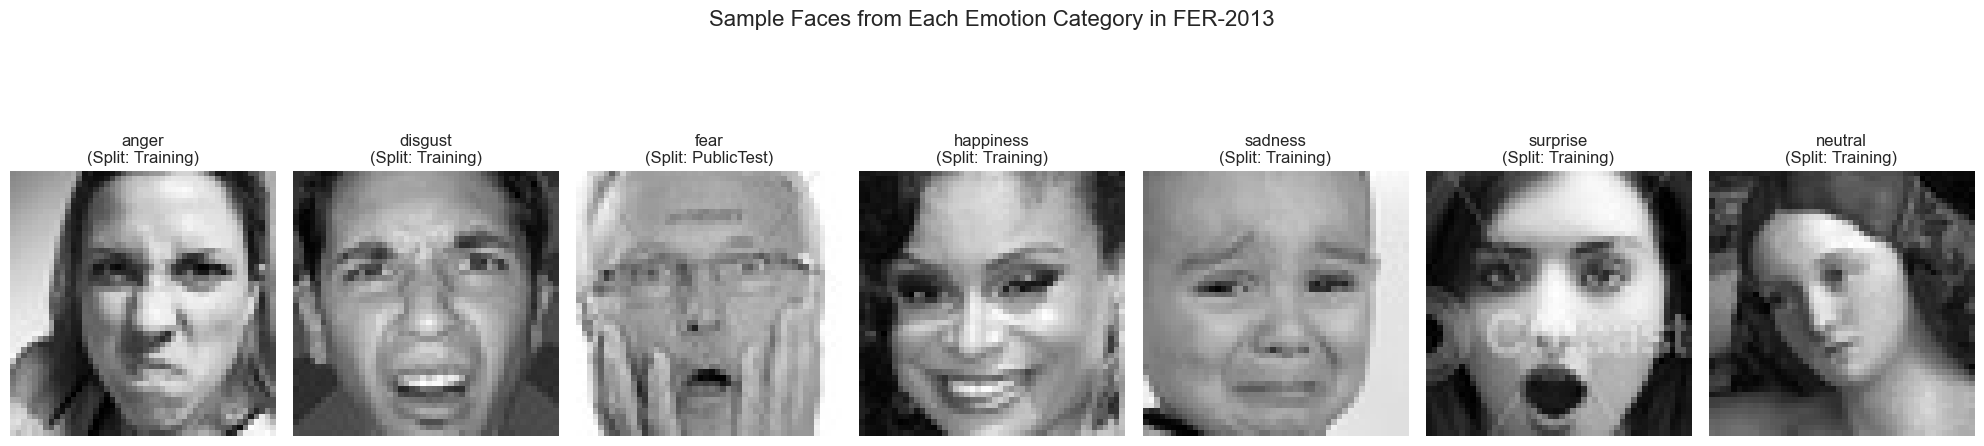

In [6]:
def get_image(pixels_str):
    """Converts pixel string from CSV into a 48x48 numpy array."""
    return np.array([int(p) for p in pixels_str.split()], dtype=np.uint8).reshape(48, 48)

# Sample one image from each emotion class
np.random.seed(42)
fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, emotion in enumerate(sorted(df["emotion"].unique())):
    sub_df = df[df["emotion"] == emotion]
    random_row = sub_df.iloc[np.random.randint(len(sub_df))]
    
    img = get_image(random_row["pixels"])
    
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"{emotion_labels[emotion]}\n(Split: {random_row['Usage']})", fontsize=12)
    axes[i].axis("off")

plt.suptitle("Sample Faces from Each Emotion Category in FER-2013", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 5. Summary of Challenges & Solutions

### Challenges:
1. **Severe Class Imbalance:**
   * The `disgust` class has only **547** training samples (1.52% of the dataset) whereas `happiness` has **8,989** (25.05%).
   * If untreated, models will naturally optimize for `happiness` and struggle with `disgust` or `fear`.
2. **Noise and Ambiguity:**
   * Many faces are off-center, misaligned, or contain hand occlusions.
   * Some facial expressions are highly ambiguous (e.g., distinguishing neutral from sad/angry or fear from surprise).

### Solutions Implemented in training:
* **Weighted Loss:** We use `--class-weights sqrt` in `src/train.py` to scale the loss of underrepresented classes (like `disgust`) to ensure they receive appropriate gradient updates.
* **Label Smoothing:** `--label-smoothing 0.1` prevents the network from over-memorizing and becoming overly confident, which is crucial for handling ambiguous/noisy labels.
* **Strong Augmentation:** `--strong-aug` (random crop, rotation, affine, RandomErasing, ColorJitter) is applied to training samples to prevent overfitting and help the model generalize to different face angles and lighting conditions.
* **Input Size Scaling (224x224):** Scaling 48x48 inputs up to 224x224 and applying ImageNet normalization allows us to use high-quality pretrained backbones (like ResNet-18 or EfficientNet-B2).